# Realistic-noise campaign — Noisy_Ladder / Noisy_Density (fixed vs formula ε)

**Purpose.** First full exploration of the realistic-noise campaign: all four noise
channels on simultaneously (σ_scatt = 1e-4, σ_res = 10 µm, drop = 1%), fixed 2 mrad
window vs formula ε = 3.178 mrad, size ladder T ∈ {10…1000} (φ_max = 0.2) and density
scan φ_max ∈ {0.01, 0.02, 0.05, 0.1, 0.2}. Step kernel, γ = 3, δ = 1.

**Provenance.** qtrk_store view (this notebook is view-driven; `max_abs_x` column =
per-solve validity gate ≤ 50). Campaign: 800 events / 1,880 solves + qsvt mirror rows;
first-look script `noisy_first_look.py` (commit `8f385a5c`), write-up
"Realistic-noise size & density study". Re-executed 2026-07-04 on the rebuilt view.

In [1]:
import os, sys, time
from pathlib import Path
for p in ("/data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/_shared",
          "/data/bfys/gscriven/LHCb_VeLo_Toy_Model/src"):
    if p not in sys.path:
        sys.path.insert(0, p)
os.environ.setdefault("QTRK_STORE", "/data/bfys/gscriven/qtrk_store")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import qtrk_pipeline as qp

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "font.size": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
})
C_CLS, C_Q, C_QSVT = "#33322e", "#e34948", "#2a78d6"
FAR_FLOOR = 5e-5   # far=0 rendered as open marker at the floor on log axes

MPATH = Path(os.environ["QTRK_STORE"]) / "manifest" / "metrics.csv"
M = pd.read_csv(MPATH)
print(f"metrics view: {len(M):,} rows, mtime {time.ctime(MPATH.stat().st_mtime)}")
print(M.solver.value_counts().to_string())

def far_plot(ax, x, y, **kw):
    """Plot false rate on a log axis with far=0 as open markers at the floor."""
    y = np.asarray(y, float)
    zero = y <= 0
    ax.plot(x, np.maximum(y, FAR_FLOOR), **kw)
    if zero.any():
        kw2 = {k: v for k, v in kw.items() if k in ("color", "marker")}
        ax.plot(np.asarray(x)[zero], np.full(zero.sum(), FAR_FLOOR),
                ls="none", mfc="white", **kw2)


metrics view: 17,239 rows, mtime Fri Jul  3 23:59:03 2026
solver
classical    13243
quantum       2117
qsvt          1879


In [2]:
N = M[M.study.str.startswith("Noisy")].copy()
N["window"] = np.where(N.eps_provenance == "set", "fixed 2 mrad", "formula 3.178 mrad")
print(N.groupby(["study", "window", "solver"]).size().unstack(fill_value=0).to_string())
C_FIX, C_FORM = "#eb6834", "#2a78d6"

solver                            classical  qsvt  quantum
study         window                                      
Noisy_Density fixed 2 mrad              640    56      112
              formula 3.178 mrad        640    47      112
Noisy_Ladder  fixed 2 mrad              160    26       28
              formula 3.178 mrad        160    26       28


## Size ladder (φ_max = 0.2): efficiency & false rate vs T, both windows, three solvers

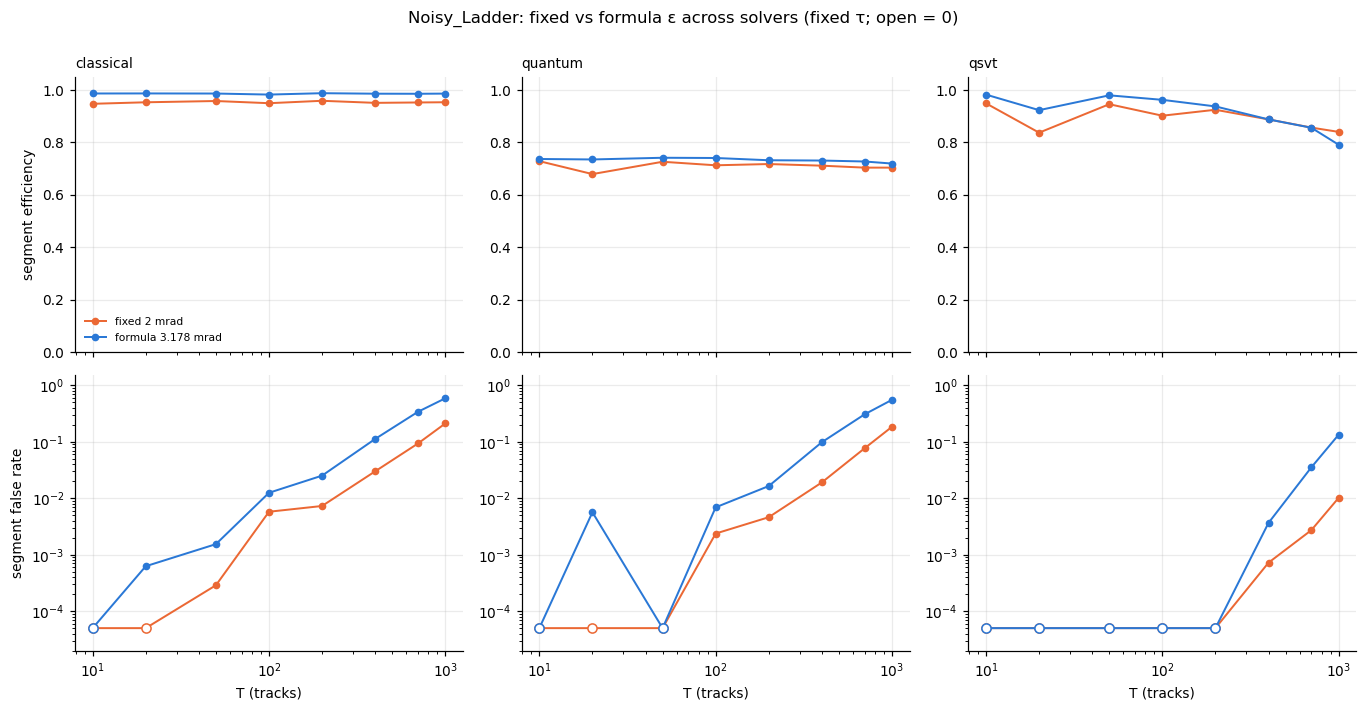

                                    segment_efficiency  segment_false_rate  segment_efficiency_wp  segment_false_rate_wp
window             solver    n_trk                                                                                      
fixed 2 mrad       classical 50               0.958055            0.000287               0.997987               0.543489
                             200              0.958917            0.007296               0.999685               0.952049
                             1000             0.953373            0.211689               1.000000               0.999000
                   qsvt      50               0.945853            0.000000               0.996633               0.326667
                             200              0.924703            0.000000               0.996847               0.565483
                             1000             0.840234            0.010180               0.999949               0.999000
                   quantum   50 

In [3]:
L = N[N.study == "Noisy_Ladder"]
fig, axes = plt.subplots(2, 3, figsize=(12.5, 6.4), sharex=True)
for j, solver in enumerate(["classical", "quantum", "qsvt"]):
    for window, c in [("fixed 2 mrad", C_FIX), ("formula 3.178 mrad", C_FORM)]:
        g = L[(L.solver == solver) & (L.window == window)].groupby("n_trk")
        if not len(g):
            continue
        axes[0, j].plot(g.segment_efficiency.mean().index, g.segment_efficiency.mean().values,
                        marker="o", ms=4, lw=1.3, color=c, label=window)
        far_plot(axes[1, j], g.segment_false_rate.mean().index, g.segment_false_rate.mean().values,
                 marker="o", ms=4, lw=1.3, color=c, label=window)
    axes[0, j].set_title(solver, loc="left", fontsize=9); axes[0, j].set_ylim(0, 1.05)
    axes[1, j].set_yscale("log"); axes[1, j].set_xscale("log"); axes[1, j].set_ylim(2e-5, 1.5)
    axes[1, j].set_xlabel("T (tracks)")
axes[0, 0].set_ylabel("segment efficiency"); axes[1, 0].set_ylabel("segment false rate")
axes[0, 0].legend(fontsize=7)
fig.suptitle("Noisy_Ladder: fixed vs formula \u03b5 across solvers (fixed \u03c4; open = 0)", y=1.0)
fig.tight_layout(); fig.savefig("figures/noisy_nb_ladder.png", bbox_inches="tight"); plt.show()
print(L[L.n_trk.isin([50, 200, 1000])].groupby(["window", "solver", "n_trk"])[
    ["segment_efficiency", "segment_false_rate", "segment_efficiency_wp",
     "segment_false_rate_wp"]].mean().to_string())

## Density scan: false rate vs T per cone, and the explosion frontier

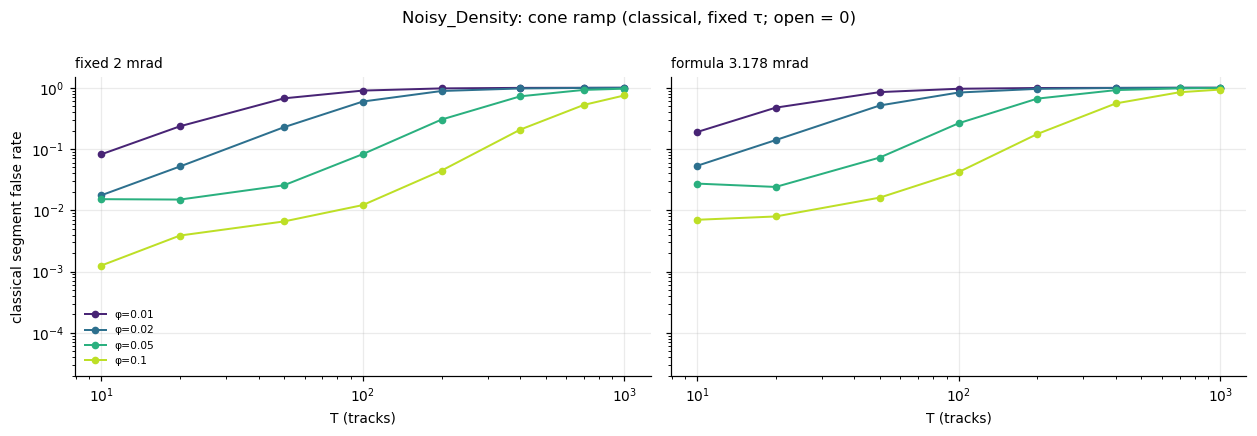

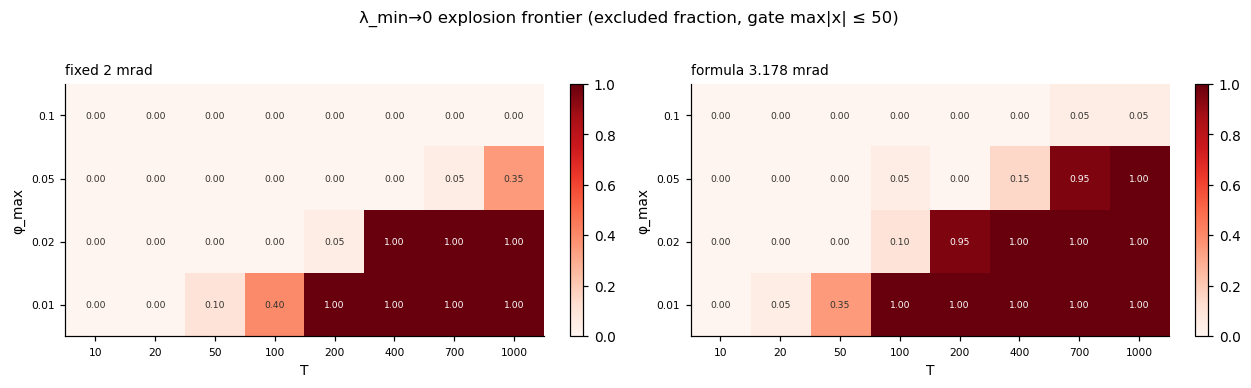

In [4]:
D = N[N.study == "Noisy_Density"]
phis = sorted(D.phi_max.unique())
ramp = plt.cm.viridis(np.linspace(0.1, 0.9, len(phis)))
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.9), sharey=True)
for ax, window in zip(axes, ["fixed 2 mrad", "formula 3.178 mrad"]):
    for phi, c in zip(phis, ramp):
        g = D[(D.solver == "classical") & (D.window == window) & (D.phi_max == phi)].groupby("n_trk")
        far_plot(ax, g.segment_false_rate.mean().index, g.segment_false_rate.mean().values,
                 marker="o", ms=4, lw=1.3, color=c, label=f"\u03c6={phi:g}")
    ax.set_yscale("log"); ax.set_xscale("log"); ax.set_ylim(2e-5, 1.5)
    ax.set_title(window, loc="left", fontsize=9); ax.set_xlabel("T (tracks)")
axes[0].set_ylabel("classical segment false rate"); axes[0].legend(fontsize=7)
fig.suptitle("Noisy_Density: cone ramp (classical, fixed \u03c4; open = 0)", y=1.0)
fig.tight_layout(); fig.savefig("figures/noisy_nb_density.png", bbox_inches="tight"); plt.show()

# explosion frontier straight from the view's max_abs_x column
exc = D[D.solver == "classical"].assign(exc=lambda d: d.max_abs_x > 50)
piv = {w: exc[exc.window == w].pivot_table(index="phi_max", columns="n_trk",
                                           values="exc", aggfunc="mean")
       for w in ["fixed 2 mrad", "formula 3.178 mrad"]}
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.4))
for ax, (w, pv) in zip(axes, piv.items()):
    im = ax.imshow(pv.values, aspect="auto", cmap="Reds", vmin=0, vmax=1, origin="lower")
    ax.set_xticks(range(len(pv.columns)), [str(t) for t in pv.columns], fontsize=7)
    ax.set_yticks(range(len(pv.index)), [f"{p:g}" for p in pv.index], fontsize=7)
    for (i, j), v in np.ndenumerate(pv.values):
        if np.isfinite(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=6,
                    color="white" if v > 0.5 else "#33322e")
    ax.set_title(w, loc="left", fontsize=9); ax.set_xlabel("T"); ax.set_ylabel("\u03c6_max")
    ax.grid(False); fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("\u03bb_min\u21920 explosion frontier (excluded fraction, gate max|x| \u2264 50)", y=1.02)
fig.tight_layout(); fig.savefig("figures/noisy_nb_explosion_map.png", bbox_inches="tight"); plt.show()

## Activation spectra at T = 200 (ladder, both windows) — streamed vectors

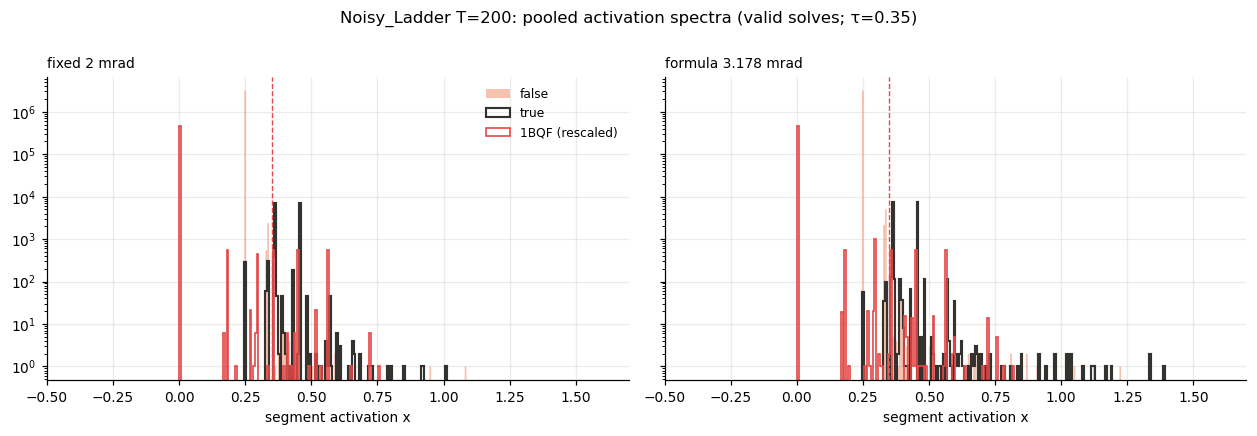

In [5]:
from qtrk_pipeline.metrics import rescale_to_signal
TAU = 0.35
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.9), sharey=True)
for ax, window in zip(axes, ["fixed 2 mrad", "formula 3.178 mrad"]):
    sel = N[(N.study == "Noisy_Ladder") & (N.n_trk == 200) & (N.window == window)]
    pt, pf, pq = [], [], []
    solc = {}
    for r in sel[sel.solver == "classical"].itertuples(index=False):
        if r.max_abs_x > 50:
            continue
        s = qp.load_solution(r.sol_key)["sol"]
        t = qp.truth_from_event(qp.load_event(qp.event_path(r.event_key))).astype(bool)
        pt.append(s[t]); pf.append(s[~t]); solc[(r.event_key, r.ham_key)] = s
    for r in sel[sel.solver == "quantum"].itertuples(index=False):
        key = (r.event_key, r.ham_key)
        if key in solc:
            pq.append(rescale_to_signal(qp.load_solution(r.sol_key)["sol"], solc[key], TAU))
    bins = np.linspace(-0.4, 1.6, 301)
    ax.hist(np.clip(np.concatenate(pf), bins[0], bins[-1]), bins=bins, histtype="stepfilled",
            alpha=0.4, color="#eb6834", label="false")
    ax.hist(np.clip(np.concatenate(pt), bins[0], bins[-1]), bins=bins, histtype="step",
            lw=1.4, color=C_CLS, label="true")
    if pq:
        ax.hist(np.clip(np.concatenate(pq), bins[0], bins[-1]), bins=bins, histtype="step",
                lw=1.1, color=C_Q, label="1BQF (rescaled)")
    ax.axvline(TAU, color=C_Q, lw=0.9, ls="--")
    ax.set_yscale("log"); ax.set_title(window, loc="left", fontsize=9)
    ax.set_xlabel("segment activation x")
axes[0].legend(fontsize=8)
fig.suptitle("Noisy_Ladder T=200: pooled activation spectra (valid solves; \u03c4=0.35)", y=1.0)
fig.tight_layout(); fig.savefig("figures/noisy_nb_spectra_T200.png", bbox_inches="tight"); plt.show()

## Findings

- **Zero explosions at φ_max = 0.2** for either window at realistic noise — the ladder is
  in the healthy regime to T = 1000; the explosion frontier is a **density × window**
  phenomenon (tight cones + wide formula window first).
- **Fixed vs formula reverses between solvers**: classically the fixed 2 mrad window wins
  at high T (~21% vs ~59% far at T = 1000) — but for the 1BQF the narrow window is *worse*
  at low T (far ~30% vs ~1% at T ≤ 50): window choice is solver-dependent.
- The true-amplitude band under the 1BQF compresses toward τ — the same working-point
  fragility documented in the ERF head-to-head; wp99 columns quantify it.